<span style="font-size:40px">Importing Libraries.</span>

In [350]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

from imblearn.over_sampling import RandomOverSampler
from IPython.display import display as dp


In [335]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

<span style="font-size:40px">Creating / Importing the dataset.</span>

In [336]:
df_AdultIncome = pd.read_csv("./Datasets/adult/adult.data")
COLS = ["AGE", "WORKCLASS", "FNLWGT", "EDUCATION", "EDUCATION-LEVEL",
                          "MARITAL-STATUS", "OCCUPATION", "RELATIONSHIP", "RACE",
                          "SEX", "CAPITAL-GAIN", "CAPITAL-LOSS", "HOURS-PER-WEEK",
                          "NATIVE-COUNTRY", "INCOME"]
df_AdultIncome.columns = COLS
df_AdultIncome = df_AdultIncome.drop(
    columns=["CAPITAL-GAIN", "CAPITAL-LOSS"]
)
COLS = COLS = ["AGE", "WORKCLASS", "FNLWGT", "EDUCATION", "EDUCATION-LEVEL",
                          "MARITAL-STATUS", "OCCUPATION", "RELATIONSHIP", "RACE",
                          "SEX", "HOURS-PER-WEEK",
                          "NATIVE-COUNTRY", "INCOME"]

In [337]:
df_AdultIncome["INCOME"] = (
    df_AdultIncome["INCOME"].str.strip() == ">50K"
).astype(int)

In [338]:
display(df_AdultIncome.head(20))
df_AdultIncome["INCOME"].value_counts()

,AGE,WORKCLASS,FNLWGT,EDUCATION,EDUCATION-LEVEL,MARITAL-STATUS,OCCUPATION,RELATIONSHIP,RACE,SEX,HOURS-PER-WEEK,NATIVE-COUNTRY,INCOME
0,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,13,United-States,0
1,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,40,United-States,0
2,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,40,United-States,0
3,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,40,Cuba,0
4,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,40,United-States,0
5,49,Private,160187,9th,5,Married-spouse-absent,Other-service,Not-in-family,Black,Female,16,Jamaica,0
6,52,Self-emp-not-inc,209642,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,45,United-States,1
7,31,Private,45781,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,50,United-States,1
8,42,Private,159449,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,40,United-States,1
9,37,Private,280464,Some-college,10,Married-civ-spouse,Exec-managerial,Husband,Black,Male,80,United-States,1


INCOME
0    24719
1     7841
Name: count, dtype: int64

In [339]:
# for label in COLS[:-1]:
#     plt.hist(df_AdultIncome[df_AdultIncome["INCOME"] == 1].head(5)[label], color = "blue", label = "Income above 50K", alpha = 0.7, density = True)
#     plt.hist(df_AdultIncome[df_AdultIncome["INCOME"] == 0].head(5)[label], color = "red", label = "Income below 50k", alpha = 0.7, density = True)
#     plt.title(label)
#     plt.ylabel("Probability")
#     plt.xlabel(label)
#     plt.legend()
#     plt.show()

<span style="font-size:40px">Creating Train, Test and Validation datasets.</span>

 Get_dummies, this is basically to make everything numerical cause if you have strings as a few datatypes for a few columns, StandardScaler wont work

In [340]:
df_AdultIncome = pd.get_dummies(
    df_AdultIncome,
    columns=[
        "WORKCLASS",
        "EDUCATION",
        "MARITAL-STATUS",
        "OCCUPATION",
        "RELATIONSHIP",
        "RACE",
        "SEX",
        "NATIVE-COUNTRY"
    ],
    dtype=int
)
df = df_AdultIncome.sample(frac=1, random_state=42).reset_index(drop=True)

train = df.iloc[:int(0.6 * len(df))]
valid = df.iloc[int(0.6 * len(df)):int(0.8 * len(df))]
test = df.iloc[int(0.8 * len(df)):]


In [341]:
df = df_AdultIncome.sample(frac=1, random_state=42).reset_index(drop=True)

train = df.iloc[:int(0.6 * len(df))]
valid = df.iloc[int(0.6 * len(df)):int(0.8 * len(df))]
test  = df.iloc[int(0.8 * len(df)):]

 Scale the dataset

In [342]:
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler
import numpy as np

def scale_dataset(dataframe, scaler=None, oversample=False, fit_scaler=False):
    # Separate features and labels
    y = dataframe["INCOME"].values
    X = dataframe.drop(columns=["INCOME"]).values

    # Fit only on training data
    if fit_scaler:
        scaler = StandardScaler()
        X = scaler.fit_transform(X)
    else:
        X = scaler.transform(X)

    # Oversample only training data
    if oversample:
        ros = RandomOverSampler(random_state=42)
        X, y = ros.fit_resample(X, y)

    data = np.hstack((X, y.reshape(-1, 1)))

    return data, X, y, scaler

In [343]:
# Training (fit scaler + oversample)
train, x_train, y_train, scaler = scale_dataset(
    train,
    oversample=True,
    fit_scaler=True
)

# Validation (reuse scaler)
valid, x_valid, y_valid, _ = scale_dataset(
    valid,
    scaler=scaler
)

# Test (reuse scaler)
test, x_test, y_test, _ = scale_dataset(
    test,
    scaler=scaler
)

# kNN
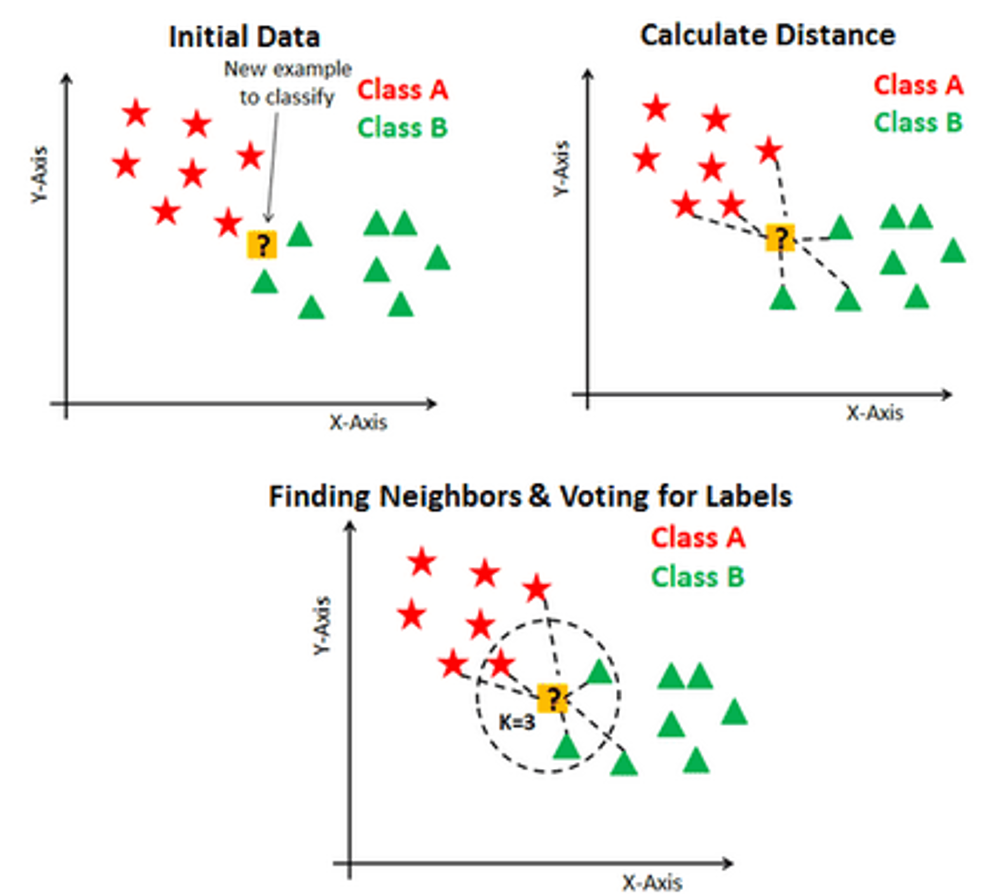

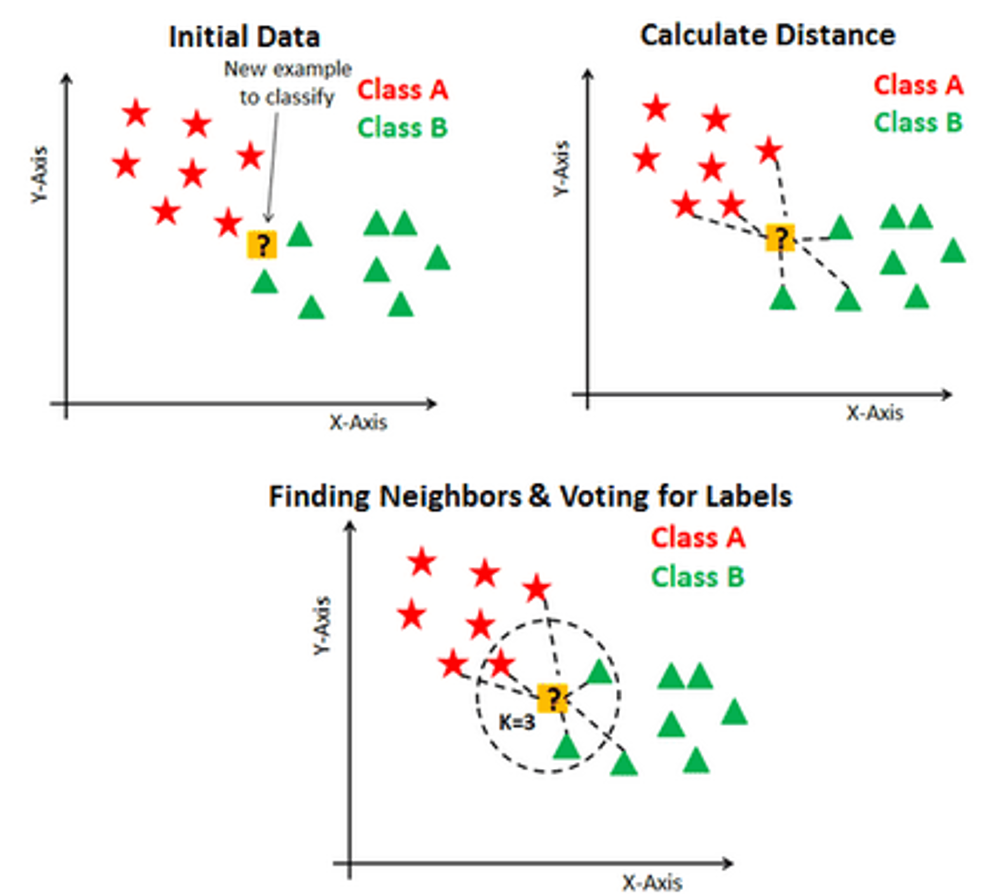

In [344]:
knn_model = KNeighborsClassifier(n_neighbors=18)
knn_model.fit(x_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",18
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [345]:
y_pred =knn_model.predict(x_test)

In [346]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.76      0.84      4975
           1       0.51      0.80      0.62      1537

    accuracy                           0.77      6512
   macro avg       0.72      0.78      0.73      6512
weighted avg       0.83      0.77      0.79      6512



# Bayes Stuff  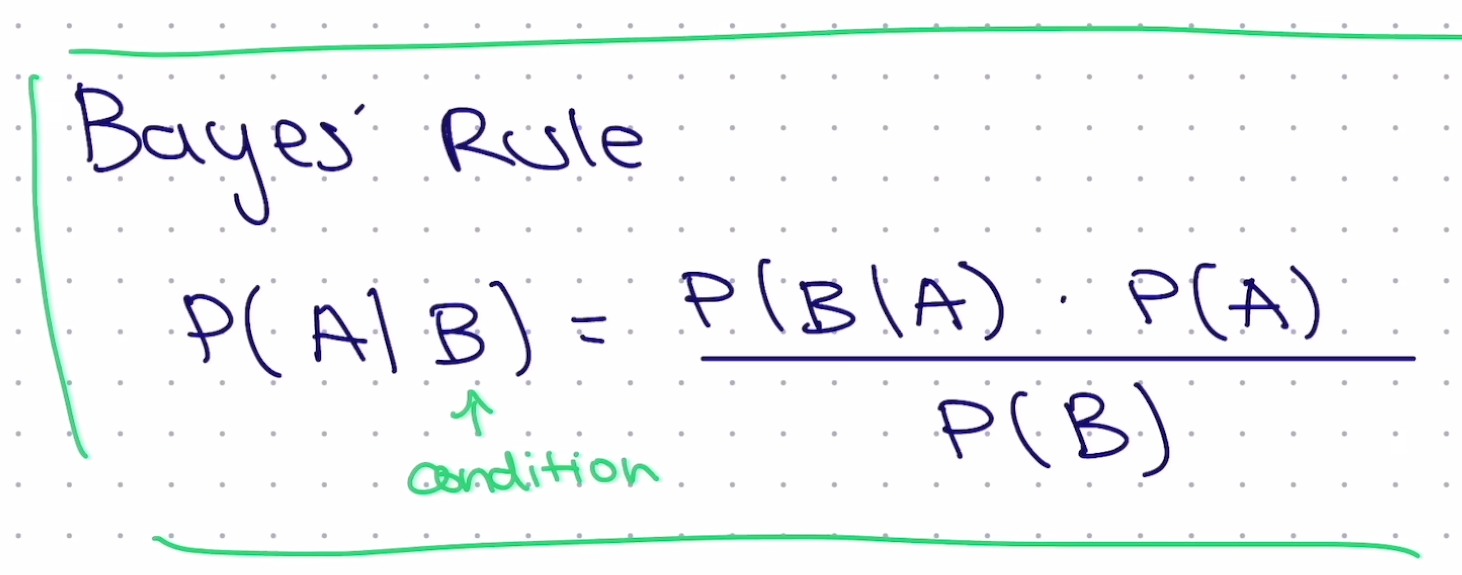

Naive Bayes ( ML application ) 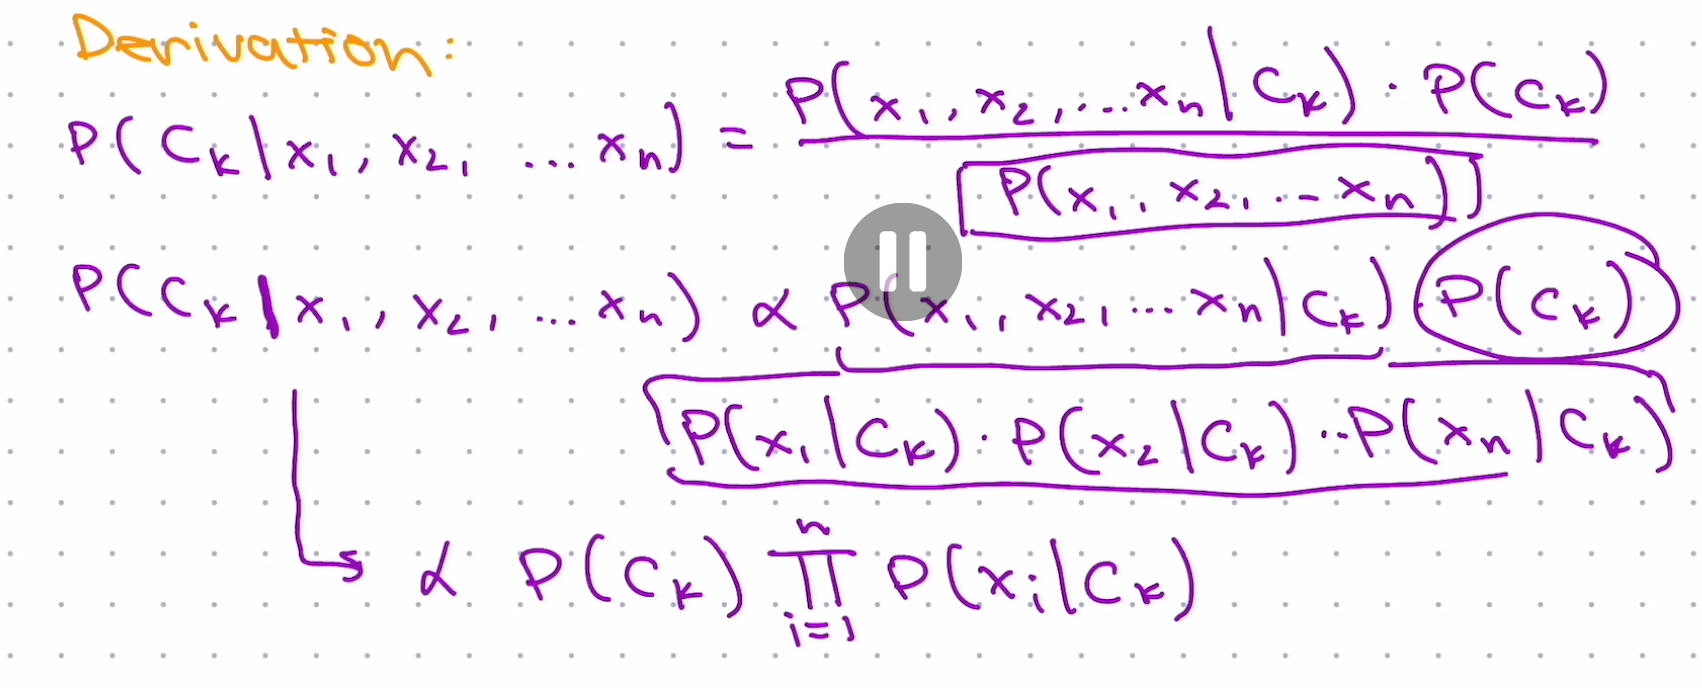

In [347]:
nb_model = GaussianNB()
nb_model = nb_model.fit(x_train, y_train)

In [348]:
y_pred = nb_model.predict(x_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.31      0.47      4975
           1       0.30      0.96      0.46      1537

    accuracy                           0.47      6512
   macro avg       0.63      0.64      0.47      6512
weighted avg       0.81      0.47      0.47      6512



# Logistic Regression

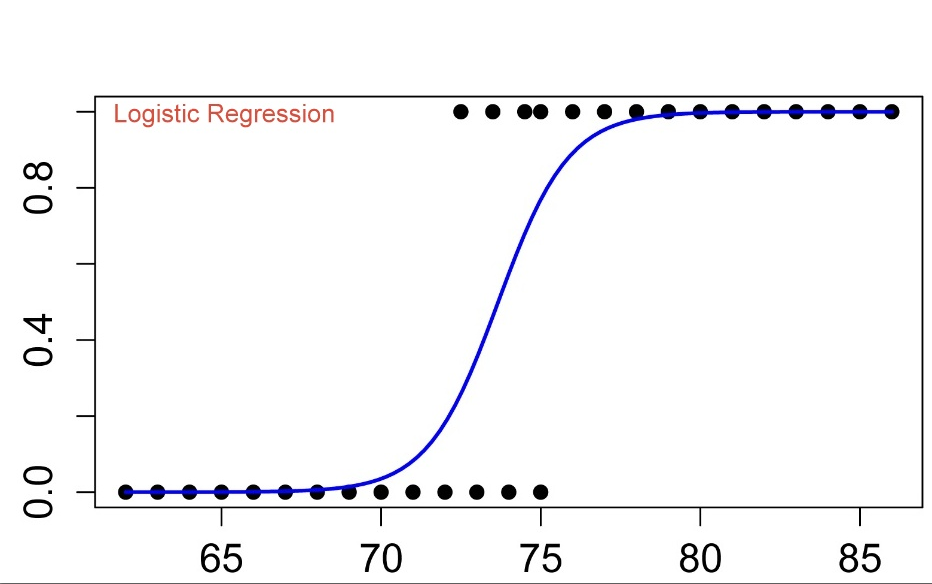

In [351]:
LR_model = LogisticRegression()
LR_model = LR_model.fit(x_train, y_train)

In [352]:
y_pred = LR_model.predict(x_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.78      0.85      4975
           1       0.54      0.84      0.66      1537

    accuracy                           0.79      6512
   macro avg       0.74      0.81      0.76      6512
weighted avg       0.85      0.79      0.81      6512

